# Coherence Estimation From Phase Ramsey

Extract the phase-index-0 Ramsey population versus wait time for compensated and uncompensated scans, then estimate T2 from the first 1/e crossing.


In [18]:
"""Estimate coherence from the zero-phase point in phase Ramsey scans.

This is a script version of the relevant ingest and raw-data processing from
``bussed_ramsey_paper_analysis.ipynb``. It does not fit each phase scan to a
sine curve. Instead, it extracts one phase point, combines repeated scans at
the same wait time, plots compensated and uncompensated data on one axis, and
estimates T2 from the first 1/e crossing.

Edit ``TARGET_TRANSITIONS`` below for the transition pair to analyze.
"""

from __future__ import annotations

import ast
import json
import math
import os
import re
from collections import defaultdict
from dataclasses import dataclass
from datetime import datetime
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np


SCRIPT_DIR = Path(r"C:\Users\iamga\OneDrive\Documents\GitHub\PhD_python_scripts\Line_signal_compensation")

PAPER_DATA_DIR = Path(
    r"Z:\Lab Data\Qudit_Ramsey_raw_data\Bussed_ramsey_detuning_calibration_data\Paper_data"
)
RAW_DATA_ROOT = Path(r"Z:\Lab Data\Qudit_Ramsey_raw_data\Raw_data_copied")

# Edit this transition pair before running, or pass --transition on the CLI.
TARGET_TRANSITIONS = [[0, 3, 2], [0, 2, 0]]

# The notebook constructs the phase axis as np.linspace(0, 2, n_phase_points).
# Index 0 is therefore the nominal zero-phase point.
ZERO_PHASE_INDEX = 0

# Default T2 convention:
#   absolute_one_over_e: ket-0 population crosses the absolute 1/e mark.
#   raw_population: ket-0 population decays to ket-0(0) / e.
#   baseline_deviation: abs(ket-0 - baseline) decays to abs(ket-0(0) - baseline) / e.
T2_REFERENCE_MODE = "absolute_one_over_e"
BASELINE_POPULATION = 0.5

OUTPUT_FIGURE = SCRIPT_DIR / "phase_zero_coherence_estimation.png"
OUTPUT_TABLE = SCRIPT_DIR / "phase_zero_coherence_estimation.csv"


@dataclass
class PaperScan:
    transitions: tuple[tuple[int, int, int], tuple[int, int, int]]
    wait_time_us: float
    lt_comp: bool
    date_time: datetime
    paper_file: Path
    raw_data_filepaths: list[Path]


@dataclass
class ZeroPhaseScan:
    wait_time_us: float
    lt_comp: bool
    population: float
    lower_error: float
    upper_error: float
    n_phase_points: int
    paper_file: Path


@dataclass
class CombinedPoint:
    wait_time_us: float
    lt_comp: bool
    population: float
    lower_error: float
    upper_error: float
    n_scans: int


@dataclass
class T2Estimate:
    lt_comp: bool
    t2_us: float | None
    threshold_population: float | None
    threshold_metric: float | None
    initial_population: float | None
    crossed: bool


def parse_paper_filename(filename: str):
    pattern = (
        r"Ramsey_experiment_\[\[\s*(-?\d+)\s*,\s*(-?\d+)\s*,\s*(-?\d+)\s*\],\s*"
        r"\[\s*(-?\d+)\s*,\s*(-?\d+)\s*,\s*(-?\d+)\s*\]\]_"
        r"(\d+(?:\.\d+)?)_us_LT_comp_(True|False)_(\d{8})_(\d{4})\.txt$"
    )
    match = re.match(pattern, filename)
    if not match:
        return None

    transitions = (
        (int(match.group(1)), int(match.group(2)), int(match.group(3))),
        (int(match.group(4)), int(match.group(5)), int(match.group(6))),
    )
    wait_time_us = float(match.group(7))
    lt_comp = match.group(8) == "True"
    date_time = datetime.strptime(match.group(9) + match.group(10), "%Y%m%d%H%M")

    return transitions, wait_time_us, lt_comp, date_time


def normalize_raw_data_path(raw_name: str, raw_data_root: Path) -> Path | None:
    raw_name = str(raw_name).strip().strip("'\"")
    if not raw_name:
        return None

    raw_path = Path(raw_name)
    if raw_path.is_absolute():
        return raw_path
    return raw_data_root / raw_name


def extract_raw_data_filenames(file_path: Path) -> list[str]:
    with open(file_path, "r", encoding="utf-8", errors="replace") as file:
        lines = [line.strip() for line in file if line.strip()]
    if not lines:
        return []

    raw_data_filenames_line = lines[-1]
    try:
        parsed = ast.literal_eval(raw_data_filenames_line)
    except Exception:
        parsed = [
            name.strip().strip("'\"")
            for name in raw_data_filenames_line.strip("[]").split(",")
            if name.strip()
        ]

    if isinstance(parsed, (list, tuple)):
        return [str(item).strip() for item in parsed if str(item).strip()]
    return [str(parsed).strip()]


def build_paper_data_index(paper_data_dir: Path, raw_data_root: Path):
    if not paper_data_dir.exists():
        raise FileNotFoundError(f"Paper data directory not found: {paper_data_dir}")

    index = defaultdict(lambda: {False: defaultdict(list), True: defaultdict(list)})
    for filename in sorted(os.listdir(paper_data_dir)):
        if not filename.startswith("Ramsey_experiment"):
            continue

        parsed = parse_paper_filename(filename)
        if parsed is None:
            continue

        transitions, wait_time_us, lt_comp, date_time = parsed
        paper_file = paper_data_dir / filename
        raw_paths = []
        for raw_name in extract_raw_data_filenames(paper_file):
            normalized = normalize_raw_data_path(raw_name, raw_data_root)
            if normalized is not None:
                raw_paths.append(normalized)

        scan = PaperScan(
            transitions=transitions,
            wait_time_us=wait_time_us,
            lt_comp=lt_comp,
            date_time=date_time,
            paper_file=paper_file,
            raw_data_filepaths=raw_paths,
        )
        index[transitions][lt_comp][wait_time_us].append(scan)

    return index


def summarize_index(index) -> list[dict]:
    rows = []
    for transitions in sorted(index.keys(), key=str):
        for lt_comp in [False, True]:
            wait_groups = index[transitions][lt_comp]
            if not wait_groups:
                continue
            rows.append(
                {
                    "transitions": [list(t) for t in transitions],
                    "LT_comp": lt_comp,
                    "n_wait_times": len(wait_groups),
                    "n_paper_files": sum(len(scans) for scans in wait_groups.values()),
                    "min_wait_us": min(wait_groups.keys()),
                    "max_wait_us": max(wait_groups.keys()),
                }
            )
    return rows


def get_shelving_threshold(counts: np.ndarray) -> float:
    counts = np.asarray(counts, dtype=float)
    counts = counts[np.isfinite(counts)]
    if counts.size == 0:
        return 11.0

    hist_counts, bin_edges = np.histogram(counts, bins=range(4, 31))
    if hist_counts.size == 0:
        return 11.0

    threshold = float(bin_edges[np.argmin(hist_counts)] + 0.5)
    if threshold < 2 or threshold > 20:
        threshold = 11.0
    return threshold


def read_histogram_rows(raw_file_path: Path) -> list:
    rows = []
    with open(raw_file_path, "r", encoding="utf-8", errors="replace") as file:
        for line in file:
            if not line.strip():
                continue
            data = json.loads(line)
            rows.append(data[0]["0"][:])
    return rows


def binomial_interval_bounds(probabilities: np.ndarray, exp_counts: np.ndarray, num_sd: float = 1.0):
    probabilities = np.asarray(probabilities, dtype=float)
    exp_counts = np.asarray(exp_counts, dtype=float)
    lower = np.full_like(probabilities, np.nan, dtype=float)
    upper = np.full_like(probabilities, np.nan, dtype=float)

    valid = np.isfinite(probabilities) & np.isfinite(exp_counts) & (exp_counts > 0)
    if not np.any(valid):
        return lower, upper

    p = probabilities[valid]
    n = exp_counts[valid]
    denom = 1.0 + (num_sd**2 / n)
    center = (p + (num_sd**2 / (2.0 * n))) / denom
    width = np.sqrt((p * (1.0 - p) * num_sd**2 / n) + (num_sd**4 / (4.0 * n**2))) / denom

    lower[valid] = center - width
    upper[valid] = center + width
    return lower, upper


def process_raw_data_files(raw_data_filepaths: list[Path]):
    """Return population and interval bounds for each phase point in one scan."""
    if not raw_data_filepaths:
        raise ValueError("raw_data_filepaths is empty")

    missing = [path for path in raw_data_filepaths if not path.exists()]
    if missing:
        raise FileNotFoundError(f"Missing raw data file: {missing[0]}")

    all_rows = []
    arrays_3d = []
    for raw_file_path in raw_data_filepaths:
        rows = read_histogram_rows(raw_file_path)
        if len(rows) == 0:
            rows = list(np.full((100, 3), 40))
        arrays_3d.append(rows)
        all_rows.extend(rows)

    threshold = get_shelving_threshold(np.asarray(all_rows).flatten())
    bool_array = np.asarray(arrays_3d) > threshold
    if bool_array.ndim != 3:
        raise ValueError(f"Expected 3D raw data array, got shape {bool_array.shape}")

    n_phase_points, n_shots, n_detection_slots = bool_array.shape
    result_matrix = np.full((n_phase_points, n_shots, max(3, n_detection_slots)), False, dtype=bool)

    for phase_index in range(n_phase_points):
        for shot_index in range(n_shots):
            data_bool = bool_array[phase_index, shot_index, :]
            if data_bool.size == 0 or data_bool[0]:
                continue
            if data_bool.size > 1 and data_bool[1]:
                result_matrix[phase_index, shot_index, 1] = True
            else:
                result_matrix[phase_index, shot_index, 2] = True

    populations = []
    exp_counts = []
    for phase_index in range(n_phase_points):
        data = result_matrix[phase_index]
        rows_with_any_true = data.any(axis=1)
        filtered_data = data[rows_with_any_true]
        exp_counts.append(len(filtered_data))

        if len(filtered_data) == 0:
            populations.append(np.nan)
        else:
            # Preserve the notebook channel convention: population is column 1.
            populations.append(float(np.mean(filtered_data, axis=0)[1]))

    populations = np.asarray(populations, dtype=float)
    lower_bounds, upper_bounds = binomial_interval_bounds(populations, np.asarray(exp_counts))
    return populations, lower_bounds, upper_bounds


def extract_zero_phase_from_scan(scan: PaperScan, zero_phase_index: int) -> ZeroPhaseScan:
    populations, lower_bounds, upper_bounds = process_raw_data_files(scan.raw_data_filepaths)
    if zero_phase_index < 0 or zero_phase_index >= len(populations):
        raise IndexError(
            f"Phase index {zero_phase_index} is outside scan with {len(populations)} phase points: "
            f"{scan.paper_file.name}"
        )

    measured_population = populations[zero_phase_index]
    measured_lower = lower_bounds[zero_phase_index]
    measured_upper = upper_bounds[zero_phase_index]

    # The raw processing returns the column-1 population; use ket-0 = 1 - column-1.
    population = 1.0 - measured_population
    lower_error = abs(population - (1.0 - measured_upper))
    upper_error = abs((1.0 - measured_lower) - population)

    return ZeroPhaseScan(
        wait_time_us=scan.wait_time_us,
        lt_comp=scan.lt_comp,
        population=float(population),
        lower_error=float(lower_error),
        upper_error=float(upper_error),
        n_phase_points=len(populations),
        paper_file=scan.paper_file,
    )


def collect_zero_phase_scans(index, target_transitions, zero_phase_index: int) -> list[ZeroPhaseScan]:
    tkey = tuple(tuple(t) for t in target_transitions)
    if tkey not in index:
        available = [row["transitions"] for row in summarize_index(index)]
        raise ValueError(
            f"Target transitions {target_transitions} are not present in the paper-data folder. "
            f"Available transition groups: {available}"
        )

    results = []
    for lt_comp in [False, True]:
        wait_groups = index[tkey][lt_comp]
        if not wait_groups:
            print(f"Warning: no paper-data scans found for LT_comp={lt_comp}.")
            continue

        print(
            f"Processing LT_comp={lt_comp}: {len(wait_groups)} wait-time groups, "
            f"{sum(len(scans) for scans in wait_groups.values())} paper scans"
        )
        for wait_time_us in sorted(wait_groups.keys()):
            scans = sorted(wait_groups[wait_time_us], key=lambda scan: scan.date_time)
            for scan in scans:
                try:
                    results.append(extract_zero_phase_from_scan(scan, zero_phase_index))
                except Exception as exc:
                    print(f"Warning: skipped {scan.paper_file.name}: {exc}")

    return results


def combine_by_wait_time(scans: list[ZeroPhaseScan]) -> list[CombinedPoint]:
    grouped = defaultdict(list)
    for scan in scans:
        grouped[(scan.lt_comp, scan.wait_time_us)].append(scan)

    combined = []
    for (lt_comp, wait_time_us), scan_group in sorted(grouped.items(), key=lambda item: (item[0][0], item[0][1])):
        populations = np.asarray([scan.population for scan in scan_group], dtype=float)
        sigmas = np.asarray(
            [
                0.5 * (scan.lower_error + scan.upper_error)
                for scan in scan_group
            ],
            dtype=float,
        )

        valid = np.isfinite(populations)
        populations = populations[valid]
        sigmas = sigmas[valid]
        if populations.size == 0:
            continue

        good_sigma = np.isfinite(sigmas) & (sigmas > 0)
        if np.any(good_sigma):
            weights = np.zeros_like(populations, dtype=float)
            weights[good_sigma] = 1.0 / sigmas[good_sigma] ** 2
            mean_population = float(np.sum(weights * populations) / np.sum(weights))
            combined_sigma = float(np.sqrt(1.0 / np.sum(weights)))
        else:
            mean_population = float(np.mean(populations))
            combined_sigma = float(np.std(populations, ddof=1) / np.sqrt(populations.size)) if populations.size > 1 else np.nan

        combined.append(
            CombinedPoint(
                wait_time_us=float(wait_time_us),
                lt_comp=bool(lt_comp),
                population=mean_population,
                lower_error=combined_sigma,
                upper_error=combined_sigma,
                n_scans=len(scan_group),
            )
        )

    return combined


def estimate_t2(
    points: list[CombinedPoint],
    lt_comp: bool,
    mode: str,
    baseline_population: float,
) -> T2Estimate:
    selected = [point for point in points if point.lt_comp == lt_comp]
    selected = sorted(selected, key=lambda point: point.wait_time_us)
    x = np.asarray([point.wait_time_us for point in selected], dtype=float)
    y = np.asarray([point.population for point in selected], dtype=float)

    valid = np.isfinite(x) & np.isfinite(y)
    x = x[valid]
    y = y[valid]
    if x.size < 2:
        return T2Estimate(lt_comp, None, None, None, float(y[0]) if y.size else None, False)

    initial_population = float(y[0])
    if mode == "absolute_one_over_e":
        metric = y
        threshold_metric = 1.0 / math.e
        threshold_population = threshold_metric
    elif mode == "baseline_deviation":
        initial_delta = initial_population - baseline_population
        initial_metric = abs(initial_delta)
        if initial_metric <= 0 or not np.isfinite(initial_metric):
            return T2Estimate(lt_comp, None, None, None, initial_population, False)
        metric = np.abs(y - baseline_population)
        threshold_metric = initial_metric / math.e
        threshold_population = baseline_population + math.copysign(threshold_metric, initial_delta)
    elif mode == "raw_population":
        initial_metric = initial_population
        if initial_metric <= 0 or not np.isfinite(initial_metric):
            return T2Estimate(lt_comp, None, None, None, initial_population, False)
        metric = y
        threshold_metric = initial_metric / math.e
        threshold_population = threshold_metric
    else:
        raise ValueError(f"Unknown T2 mode: {mode}")

    if np.isfinite(metric[0]) and metric[0] == threshold_metric:
        return T2Estimate(
            lt_comp=lt_comp,
            t2_us=float(x[0]),
            threshold_population=float(threshold_population),
            threshold_metric=float(threshold_metric),
            initial_population=initial_population,
            crossed=True,
        )

    for idx in range(1, len(x)):
        prev_metric = metric[idx - 1]
        curr_metric = metric[idx]
        if not (np.isfinite(prev_metric) and np.isfinite(curr_metric)):
            continue

        prev_offset = prev_metric - threshold_metric
        curr_offset = curr_metric - threshold_metric
        if curr_offset == 0:
            t2_us = float(x[idx])
        elif prev_offset == 0:
            t2_us = float(x[idx - 1])
        elif prev_offset * curr_offset < 0:
            fraction = (threshold_metric - prev_metric) / (curr_metric - prev_metric)
            t2_us = float(x[idx - 1] + fraction * (x[idx] - x[idx - 1]))
        else:
            continue

        return T2Estimate(
            lt_comp=lt_comp,
            t2_us=t2_us,
            threshold_population=float(threshold_population),
            threshold_metric=float(threshold_metric),
            initial_population=initial_population,
            crossed=True,
        )

    return T2Estimate(
        lt_comp=lt_comp,
        t2_us=None,
        threshold_population=float(threshold_population),
        threshold_metric=float(threshold_metric),
        initial_population=initial_population,
        crossed=False,
    )


def transition_label(target_transitions) -> str:
    return f"{list(target_transitions[0])} -> {list(target_transitions[1])}"


def plot_zero_phase_coherence(
    points: list[CombinedPoint],
    target_transitions,
    t2_estimates: dict[bool, T2Estimate],
    output_figure: Path,
    show: bool,
):
    fig, ax = plt.subplots(figsize=(10, 6))
    colors = {False: "tab:blue", True: "tab:orange"}
    labels = {False: "Uncompensated", True: "Compensated"}

    for lt_comp in [False, True]:
        selected = [point for point in points if point.lt_comp == lt_comp]
        if not selected:
            continue
        selected = sorted(selected, key=lambda point: point.wait_time_us)
        x = np.asarray([point.wait_time_us for point in selected], dtype=float)
        y = np.asarray([point.population for point in selected], dtype=float)
        yerr = np.asarray(
            [
                [point.lower_error for point in selected],
                [point.upper_error for point in selected],
            ],
            dtype=float,
        )

        estimate = t2_estimates[lt_comp]
        if estimate.crossed:
            label = f"{labels[lt_comp]} (T2 = {estimate.t2_us:.0f} us)"
        else:
            label = f"{labels[lt_comp]} (no 1/e crossing)"

        ax.errorbar(
            x,
            y,
            yerr=yerr,
            fmt="o-",
            capsize=3,
            color=colors[lt_comp],
            ecolor=colors[lt_comp],
            label=label,
            markersize=6,
            linewidth=1.5,
            alpha=0.85,
        )

        if estimate.threshold_population is not None:
            ax.axhline(
                estimate.threshold_population,
                color=colors[lt_comp],
                linestyle="--",
                linewidth=1.0,
                alpha=0.6,
            )
        if estimate.t2_us is not None:
            ax.axvline(
                estimate.t2_us,
                color=colors[lt_comp],
                linestyle=":",
                linewidth=1.2,
                alpha=0.7,
            )

    ax.set_xlabel("Wait time (us)")
    ax.set_ylabel("Ket 0 population at phase index 0")
    ax.set_title(f"Zero-phase Ramsey coherence: {transition_label(target_transitions)}")
    ax.set_ylim(-0.05, 1.05)
    ax.grid(True, alpha=0.35)
    ax.legend()
    fig.tight_layout()

    output_figure.parent.mkdir(parents=True, exist_ok=True)
    fig.savefig(output_figure, dpi=300)
    print(f"Saved figure: {output_figure}")
    if show:
        plt.show()
    else:
        plt.close(fig)


def save_combined_table(points: list[CombinedPoint], output_table: Path):
    output_table.parent.mkdir(parents=True, exist_ok=True)
    with open(output_table, "w", encoding="utf-8") as file:
        file.write("LT_comp,wait_time_us,ket0_population,lower_error,upper_error,n_scans\n")
        for point in sorted(points, key=lambda item: (item.lt_comp, item.wait_time_us)):
            file.write(
                f"{point.lt_comp},{point.wait_time_us:.12g},{point.population:.12g},"
                f"{point.lower_error:.12g},{point.upper_error:.12g},{point.n_scans}\n"
            )
    print(f"Saved table: {output_table}")


Selected transition: [0, 3, 2] -> [0, 2, 0]
Phase index: 0
T2 mode: absolute_one_over_e
Found 4 transition/LT_comp groups in Z:\Lab Data\Qudit_Ramsey_raw_data\Bussed_ramsey_detuning_calibration_data\Paper_data
Processing LT_comp=False: 21 wait-time groups, 158 paper scans
Processing LT_comp=True: 21 wait-time groups, 155 paper scans
Uncompensated: initial ket0=0.9815, 1/e population mark=0.3679, T2=1113.33 us
Compensated: initial ket0=0.9968, 1/e population mark=0.3679, no crossing in measured wait-time range
Saved table: C:\Users\iamga\OneDrive\Documents\GitHub\PhD_python_scripts\Line_signal_compensation\phase_zero_coherence_estimation.csv
Saved figure: C:\Users\iamga\OneDrive\Documents\GitHub\PhD_python_scripts\Line_signal_compensation\phase_zero_coherence_estimation.png


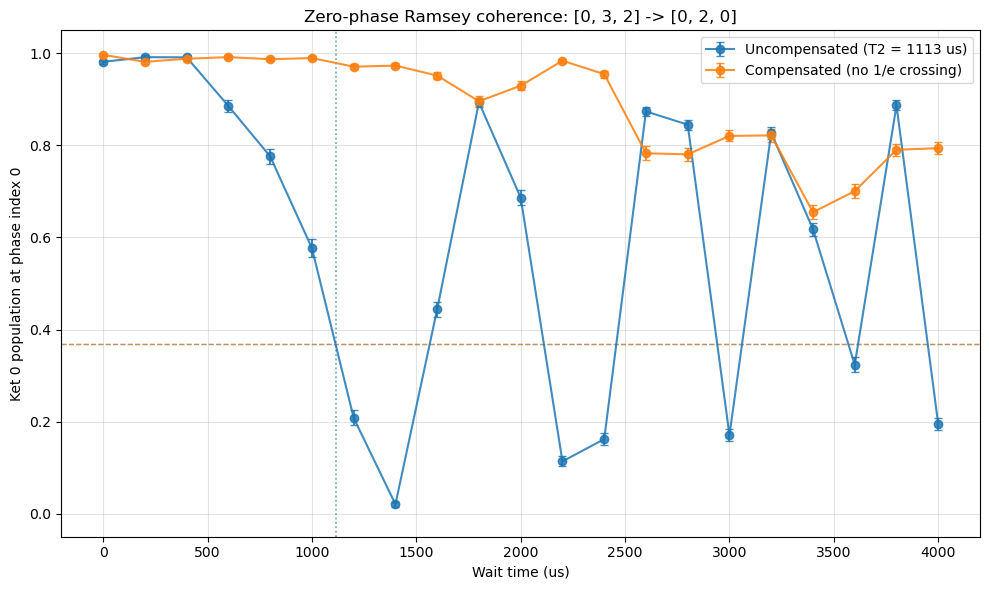

In [19]:
# Run the zero-phase coherence analysis.
# Edit TARGET_TRANSITIONS in the definitions/config cell above, or override it here.
# TARGET_TRANSITIONS = [[0, 3, -1], [0, 2, 0]]

print(f"Selected transition: {transition_label(TARGET_TRANSITIONS)}")
print(f"Phase index: {ZERO_PHASE_INDEX}")
print(f"T2 mode: {T2_REFERENCE_MODE}")

paper_index = build_paper_data_index(PAPER_DATA_DIR, RAW_DATA_ROOT)
summary_rows = summarize_index(paper_index)
print(f"Found {len(summary_rows)} transition/LT_comp groups in {PAPER_DATA_DIR}")

zero_phase_scans = collect_zero_phase_scans(
    paper_index,
    TARGET_TRANSITIONS,
    ZERO_PHASE_INDEX,
)
if not zero_phase_scans:
    raise RuntimeError("No zero-phase scan results were produced.")

combined_points = combine_by_wait_time(zero_phase_scans)
if not combined_points:
    raise RuntimeError("No combined wait-time points were produced.")

estimates = {
    lt_comp: estimate_t2(
        combined_points,
        lt_comp,
        T2_REFERENCE_MODE,
        BASELINE_POPULATION,
    )
    for lt_comp in [False, True]
}

for lt_comp, estimate in estimates.items():
    tag = "Compensated" if lt_comp else "Uncompensated"
    if estimate.crossed:
        print(
            f"{tag}: initial ket0={estimate.initial_population:.4f}, "
            f"1/e population mark={estimate.threshold_population:.4f}, "
            f"T2={estimate.t2_us:.2f} us"
        )
    elif estimate.threshold_population is not None:
        print(
            f"{tag}: initial ket0={estimate.initial_population:.4f}, "
            f"1/e population mark={estimate.threshold_population:.4f}, "
            "no crossing in measured wait-time range"
        )
    else:
        print(f"{tag}: not enough finite data for a T2 estimate")

save_combined_table(combined_points, OUTPUT_TABLE)
plot_zero_phase_coherence(
    combined_points,
    TARGET_TRANSITIONS,
    estimates,
    OUTPUT_FIGURE,
    show=True,
)
